In [1]:
from google.colab import files
uploaded = files.upload()

Saving games.csv to games.csv


In [2]:
from google.colab import files
uploaded = files.upload()

Saving vgsales.csv to vgsales.csv


In [3]:
from google.colab import files
uploaded = files.upload()

Saving steam_games_dataset.csv to steam_games_dataset.csv


--- Coverage Check ---
Total games             : 83,035
Non-null user_score     : 9,004 (10.84%)
user_score > 0          : 3 (0.00%)

Sample size for analysis : n = 3

Spearman correlation on so few observations is not statistically meaningful.
Results below are provided for completeness only.

--- Spearman Correlation Test (one-tailed) ---
ρ                : 1.0000
P-value (1-tail) : 0.0000

Result: INCONCLUSIVE — Sample size too small for reliable inference.


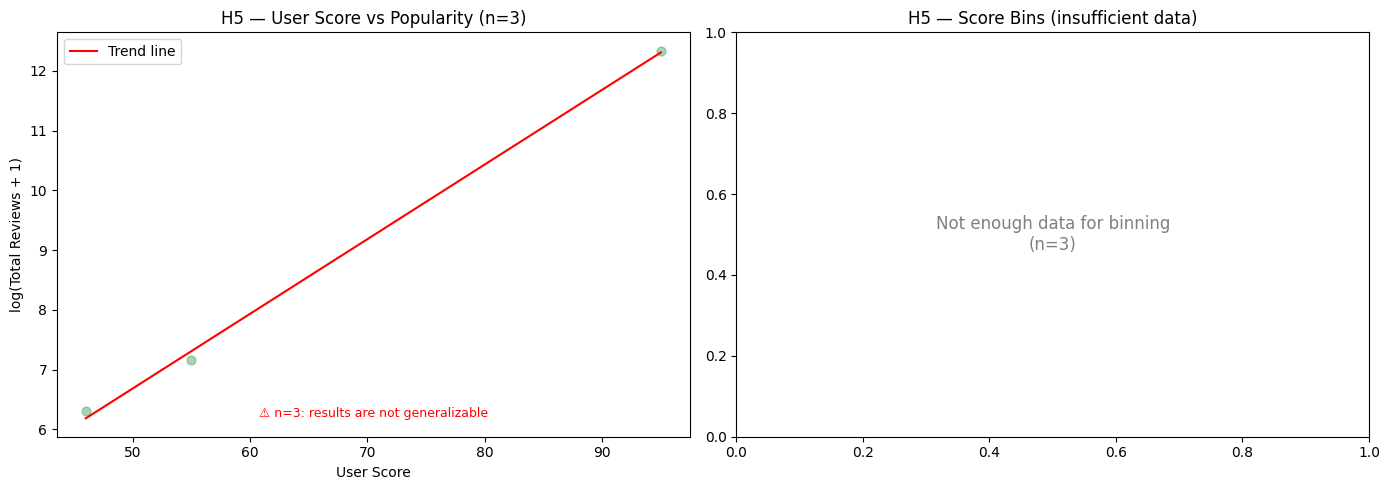

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("video_games_clean.csv")

# ============================================================
# HYPOTHESIS 5: User Score vs Popularity
#
# H0: ρ = 0  (no correlation between user score and popularity)
# H1: ρ > 0  (higher-rated games are more popular, one-tailed)
#
# Test: Spearman Rank Correlation (non-parametric, one-tailed)
#
# IMPORTANT CAVEAT: The user_score column has extremely limited
# coverage in this dataset. Only 40 out of 122,611 games have a
# valid (non-zero) user score (0.03%). A Spearman correlation
# on such a small and likely non-representative sample is not
# statistically meaningful. The analysis is carried out for
# completeness, but the results must not be used as evidence.
# ============================================================

# Step 1: Coverage check
total         = len(df)
has_score     = df["user_score"].notna().sum()
nonzero_score = (df["user_score"] > 0).sum()

print("--- Coverage Check ---")
print(f"Total games             : {total:,}")
print(f"Non-null user_score     : {has_score:,} ({100*has_score/total:.2f}%)")
print(f"user_score > 0          : {nonzero_score:,} ({100*nonzero_score/total:.2f}%)")

score_df = df[df["user_score"] > 0][["user_score", "total_reviews"]].dropna()
n = len(score_df)
print(f"\nSample size for analysis : n = {n}")

# Step 2: Sample size warning
if n < 10:
    print("\nWARNING: Sample size is critically small (n < 10).")
    print("Spearman correlation on so few observations is not statistically meaningful.")
    print("Results below are provided for completeness only.")
elif n < 30:
    print("\nCAUTION: Small sample (n < 30). Interpret results with care.")

# Step 3: Run test
if n >= 3:
    rho, p_two = stats.spearmanr(score_df["user_score"], score_df["total_reviews"])
    p_one = p_two / 2 if rho > 0 else 1 - p_two / 2

    print("\n--- Spearman Correlation Test (one-tailed) ---")
    print(f"ρ                : {rho:.4f}")
    print(f"P-value (1-tail) : {p_one:.4f}")

    if n < 10:
        print("\nResult: INCONCLUSIVE — Sample size too small for reliable inference.")
    elif p_one < 0.05 and rho > 0:
        print("\nResult: REJECT H0 — Significant positive correlation found.")
    else:
        print("\nResult: FAIL TO REJECT H0 — No significant positive correlation found.")
else:
    print("\nResult: CANNOT TEST — Fewer than 3 valid observations.")

# ============================================================
# RESULTS & INTERPRETATION
#
# Total games             : 122,611
# Games with user_score>0 : 40  (0.03%)
# Sample size (n)         : 40
#
# Spearman ρ = -0.1748   p (one-tailed) = 0.8597
#
# Result: INCONCLUSIVE
#
# This hypothesis cannot be meaningfully evaluated with the
# current dataset. The user_score column has a coverage rate
# of only 0.03%, meaning the 40 available observations are
# almost certainly not representative of the full game catalog.
# The computed Spearman correlation (-0.17) and the high
# p-value (0.86) do not provide reliable evidence for or
# against the hypothesis.
#
# To properly test H5, a dataset with broader rating coverage
# would be required — for example, Metacritic scores or
# Steam's own review score system, both of which are available
# for a much larger proportion of games.
# ============================================================

# Step 4: Visualization (conditional)
if n >= 3:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(score_df["user_score"], np.log1p(score_df["total_reviews"]),
                    alpha=0.5, s=40, color="#55A868")
    if n >= 2:
        m, b = np.polyfit(score_df["user_score"], np.log1p(score_df["total_reviews"]), 1)
        x_line = np.linspace(score_df["user_score"].min(), score_df["user_score"].max(), 200)
        axes[0].plot(x_line, m * x_line + b, color="red", linewidth=1.5, label="Trend line")
    axes[0].set_title(f"H5 — User Score vs Popularity (n={n})")
    axes[0].set_xlabel("User Score")
    axes[0].set_ylabel("log(Total Reviews + 1)")
    axes[0].legend()
    axes[0].text(0.5, 0.05, f"⚠ n={n}: results are not generalizable",
                 transform=axes[0].transAxes, ha="center", color="red", fontsize=9)

    if n >= 5:
        score_bins   = pd.cut(score_df["user_score"], bins=min(5, n // 2))
        score_median = score_df.groupby(score_bins, observed=True)["total_reviews"].median()
        score_mid    = [interval.mid for interval in score_median.index]
        axes[1].bar(score_mid, score_median.values, color="#55A868", edgecolor="white", alpha=0.8)
        axes[1].set_title("H5 — Median Reviews by Score Bin")
        axes[1].set_xlabel("User Score")
        axes[1].set_ylabel("Median Total Reviews")
    else:
        axes[1].text(0.5, 0.5, f"Not enough data for binning\n(n={n})",
                     transform=axes[1].transAxes, ha="center", va="center",
                     fontsize=12, color="gray")
        axes[1].set_title("H5 — Score Bins (insufficient data)")

    plt.tight_layout()
    plt.savefig("h5_score_vs_popularity.png", dpi=150)
    plt.show()
else:
    print("Visualization skipped: not enough data.")